In [1]:
#import datetime as dt
import cftime 
from datetime import datetime as py_datetime

import time
import datetime
from datetime import datetime as py_datetime
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

In [2]:
import ens

In [3]:
import netCDF4 as ncdf
import numpy as N
import math as M
import glob
import sys
import os
import re

import matplotlib
import matplotlib.pyplot as P
from matplotlib import ticker
from matplotlib.offsetbox import AnchoredText

import json
from pyproj import Proj
from time import time as timer
from pyDart import dll_2_dxy, dxy_2_dll
import pyDart
import datetime
from subprocess import *
#from cbook2 import *
import ctables
from optparse import OptionParser
import scipy.interpolate
import scipy.ndimage as ndimage
import scipy.spatial

from mpl_toolkits.basemap import Basemap

from fsrc.fpython2 import fstate, addbubbles_box, obs_2_grid3d
from fsrc.fpython2 import add_smooth_perts
#import fsrc.recursive2d as recursive2d

import state_vector as state

from ens import read_CM1_ens


def ens_PLOT_9PANEL(ens, klevel = 6, obs=False, savefig=None, cparams = None, var='DBZ', 
                    zoom = None, **kwargs):
#
#===============================================================================

# get gridded observations

  if obs:
     f3d = ens_GRID_RELECTIVITY(ens, cref=False)
     print("\n --> PLOT_9PANEL:  Interpolated reflectivity")

  fig, ax_grid = P.subplots(3, 3, figsize=(12,12), sharex=True, sharey=True)

  map = mymap(fstate.xc, fstate.yc, ens.lat0, ens.lon0, counties=False, noticks=False)
  lon2d, lat2d, x2d, y2d = map.makegrid(fstate.xc.size, fstate.yc.size, returnxy=True)

  if ens.ne <= 20:
     mem = N.arange(0,20,1)
  elif ens.ne <= 30:
     mem = N.arange(0,30,3)
  elif ens.ne <= 40:
     mem = N.arange(0,36,4)
  elif ens.ne <= 50:
     mem = N.arange(0,45,5)
  else:
     mem = N.arange(0,54,6)
     
  if cparams == None:
      cparams = _clevels[var]

  clevels = N.arange(cparams[0], cparams[1], cparams[2])

  for n, ax in enumerate(ax_grid.ravel()):
    
    if n == 4 and obs:
      mfld = N.ma.masked_less_equal(f3d[5,:,:], 0.0)
      label = "OBSERVED DBZ"
      PLOT_ONE(mfld, x2d, y2d, map, clevels=clevels, height=ens.zc[5], label = label, ax = ax, \
               counties=True, cmap=ctables.REF_default, zoom = zoom, **kwargs)
    else:
      print("\n Plotting member %d" % (mem[n]+1))
      if var == "DBZ":
          mfld = N.ma.masked_less_equal(ens['DBZ'][mem[n],klevel,:,:], 10.)
          label = "DBZ Mem: %2.2d" % (mem[n]+1)
          PLOT_ONE(mfld, x2d, y2d, map, clevels=clevels, height=ens.zc[klevel], label = label, ax = ax, \
               counties=True, cmap=ctables.REF_default, zoom = zoom)
      else:
          if var == "THP":
              mfld = N.clip(ens['TH'][mem[n],klevel,:,:] - ens['TH'][mem[n],klevel,-1,1], cparams[0],cparams[1])
          elif var == "WZ":
              mfld = 10000.*ComputeWZ(fstate.xc, fstate.yc, fstate.u[mem[n],klevel], fstate.v[mem[n],klevel])
          else:
              mfld = N.clip(ens[var][mem[n],klevel,:,:],cparams[0],cparams[1])

          label = "%s Mem: %2.2d" % (var,mem[n]+1)
          PLOT_ONE(mfld, x2d, y2d, map, clevels=clevels, height=ens.zc[klevel], label = label, ax = ax, \
                   counties=True, cmap=ens_default_cmap, zoom = zoom)

  dx = ens.xc[2] - ens.xc[1]
  title = ("%s  Microphysics:  %s   DX = %4.1f km" % (ens.datetime[0].strftime("%Y_%m_%d  %H:%M:%S"),ens.experiment['microphysics'],
                   dx/1000.))
  fig.suptitle(title, fontsize=12)
  

In [2]:
file = '/work/jessica.mcdonald/CM1_LETKF_2025/RUN_LETKF/member001/cm1rst_000004.nc'

f = ncdf.Dataset(file, "r+")
f.close()

In [6]:
# VALUS FROM PYDART
map_projection     = 'latlon'  # valid projects are lambert conformal ['lcc'], and latlon ['latlon']
truelat1, truelat2 = 30.0, 60.0

#not in pydart, its sort set? 

def dxy_2_dll(x, y, lat1, lon1, degrees=True, proj = map_projection):

  """dxy_2_dll returns the approximate lat/lon between an x,y coordinate and
     a reference lat/lon point.  

     Valid projections: Lambert Conformal 
                        Lat - Lon

     INPUTS:  x,y in meters, lat1, lon1 in radians, or if degrees == True, 
              then degrees (default value)

     if x > 0, lon > lon1

     if y > 0, lat > lat1

     OUTPUTS:  lat, lon in radians, or if degrees == True, degrees
               i.e., the input and output units for lat/lon are held the same.
  """

  if degrees:
    rlon1 = N.deg2rad(lon1)
    rlat1 = N.deg2rad(lat1)
  else:
    rlon1 = lon1
    rlat1 = lat1

# Simple Lat-Lon grid

  if proj == 'latlon':
    rearth = 1000.0 * 6367.0
    rlat2  = rlat1 + y / rearth
    lon    = N.rad2deg(rlon1 + x / ( rearth * N.cos(0.5*(rlat1+rlat1)) ) )
    lat    = N.rad2deg(rlat2)

# Lambert Conformal

  if proj == 'lcc':
    p1 = Proj(proj='lcc', ellps='WGS84', datum='WGS84', lat_1=truelat1, lat_2=truelat2, lat_0=lat1, lon_0=lon1)
    lon, lat = p1(x, y, inverse = True)

  if degrees == False:
    return N.deg2rad(lat), N.deg2rad(lon)
  else:
    return lat, lon

In [7]:
# lat1   =  state.lat0
# lon1   = state.lon0
# truelat1  =  30.0,
# truelat2  =  60.0,

noticks = False
resolution='c'
area_thresh = None
shape_env = False
counties=False
pickle = False
ax=None

In [25]:

myDTstring = '2003,05,08,21,10,00'

with open('/work/jessica.mcdonald/CM1_LETKF_2025/RUN_LETKF/RUN_LETKF.exp', 'rb') as f:
    exper = json.load(f)
files, myDT = ens.FindRestartFiles(exper, myDTstring, ret_exp=False,)

state = ens.read_CM1_ens(files, exper, state_vector=None, DateTime=myDT, addmean=1)
ens.ens_CM1_coords(state)


 ==> FindRestartFiles: Date and time supplied is 2003_05_08 21:10:00

 ==> FindRestartFile:  Found time 1800 in file:  /work/jessica.mcdonald/CM1_LETKF_2025/RUN_LETKF/member001/cm1rst_000006.nc

 ==> READ_CM1_ENS:  No state_vector supplied - trying to match microphysics schemes

 ==> READ_CM1_ENS ==> Matching state_vector found !!! using zvdh

 ==> READ_CM1_ENS: reading from time INDEX:  0
 ==> READ_CM1_ENS: reading from state TIME:  2003-05-08 21:10:00 


 Wallclock time for serial read netCDF ensemble files: 0.123  sec

 Wallclock time to convert from C to A grid: 0.019  sec

 Wallclock time to create ensemble means: 0.068  sec

 Wallclock time to read arrays from netCDF ensemble files: 0.266  sec

 Wallclock time to create coordinates: 0.0  sec


/work/jessica.mcdonald/CM1_LETKF_2025/ens.py:1765: RuntimeWarning: overflow encountered in multiply
  fstate.xyz3d[ens.u_ptr,:,:,:,1:nx-1] = (-fstate.u[:,:,:,0:nx-2]  + 13.0*fstate.u[:,:,:,1:nx-1] \
/work/jessica.mcdonald/CM1_LETKF_2025/ens.py:1765: RuntimeWarning: invalid value encountered in multiply
  fstate.xyz3d[ens.u_ptr,:,:,:,1:nx-1] = (-fstate.u[:,:,:,0:nx-2]  + 13.0*fstate.u[:,:,:,1:nx-1] \
/work/jessica.mcdonald/CM1_LETKF_2025/ens.py:1765: RuntimeWarning: overflow encountered in add
  fstate.xyz3d[ens.u_ptr,:,:,:,1:nx-1] = (-fstate.u[:,:,:,0:nx-2]  + 13.0*fstate.u[:,:,:,1:nx-1] \
/work/jessica.mcdonald/CM1_LETKF_2025/ens.py:1765: RuntimeWarning: invalid value encountered in add
  fstate.xyz3d[ens.u_ptr,:,:,:,1:nx-1] = (-fstate.u[:,:,:,0:nx-2]  + 13.0*fstate.u[:,:,:,1:nx-1] \
/work/jessica.mcdonald/CM1_LETKF_2025/ens.py:1765: RuntimeWarning: overflow encountered in subtract
  fstate.xyz3d[ens.u_ptr,:,:,:,1:nx-1] = (-fstate.u[:,:,:,0:nx-2]  + 13.0*fstate.u[:,:,:,1:nx-1] \
/work

In [9]:
from ens import _clevels, PLOT_ONE

In [21]:
N.shape(state['DBZ'][:])

(4, 51, 75, 75)

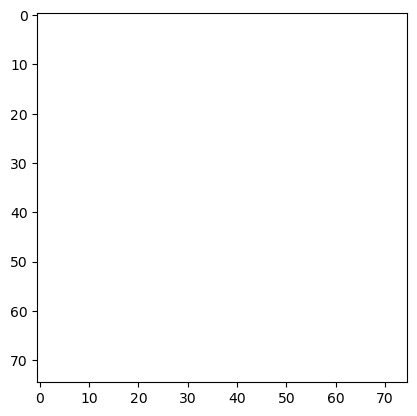

In [24]:
mfld = N.ma.masked_less_equal(state['DBZ'][:][mem[n],30,:,:], 10.)

plt.imshow(mfld)


 ==> ens_GRID_REFL: Using pyDart to search with begin time of:  2003-05-08 21:07:30

 ==> ens_GRID_REFL: Using pyDart to search with end   time of:  2003-05-08 21:12:30
  pyDART.search:  no variable supplied....all vars dumped
  pyDART.search:  Start datetime:  2003-05-08 21:07:30
  pyDART.search:  End datetime:  2003-05-08 21:07:30

  pyDART file is version:  pyDART_file_version_2.3 
  \/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/

  PyDART SEARCH START TIME  2003-05-08 21:07:30  /  UTIME_START: 1052428050
  PyDART SEARCH END   TIME  2003-05-08 21:12:30  /  UTIME_END:   1052428350
  PyDART converted utimes: 2003-05-08 21:07:30

  PyDART SEARCH CONDITION IS: (1052428050 <= utime) & (utime < 1052428350) & (kind == 12) & (value > 0.) & (z < 10000.)

  ==> ens_GRID_REFL:  Total number of obs found at search time: 4001 


  pyDART file is version:  pyDART_file_version_2.3 
  \/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/


 ==> ens_GRID_REFL: Number of points foun

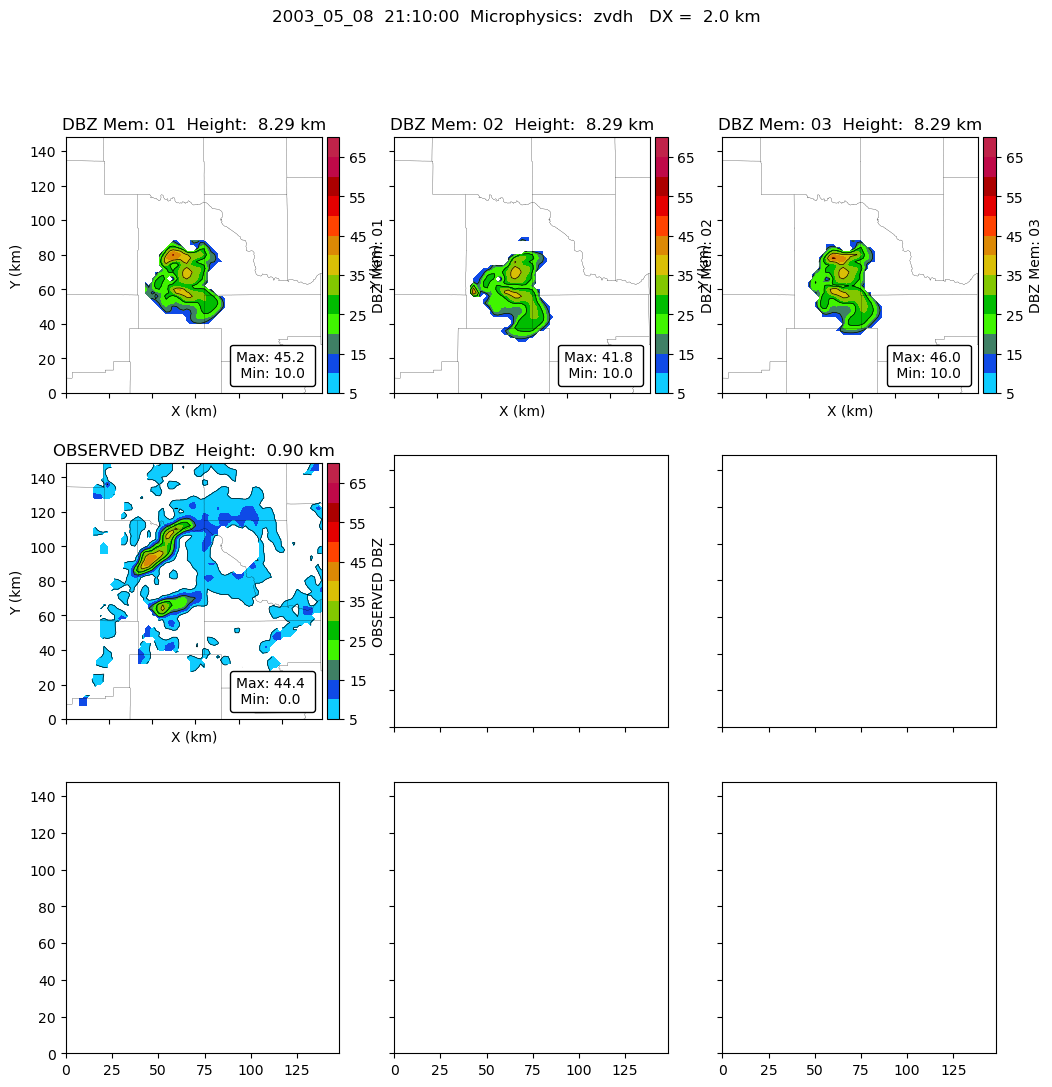

In [29]:
obs=True
cparams=None
var='DBZ'
klevel=30
zoom=False
if obs:
    f3d = ens.ens_GRID_RELECTIVITY(state, cref=False)
    print("\n --> PLOT_9PANEL:  Interpolated reflectivity")

fig, ax_grid = P.subplots(3, 3, figsize=(12,12), sharex=True, sharey=True)

map = ens.mymap(fstate.xc, fstate.yc, state.lat0, state.lon0, counties=False, noticks=False)
lon2d, lat2d, x2d, y2d = map.makegrid(fstate.xc.size, fstate.yc.size, returnxy=True)

if state.ne <= 20:
    mem = N.arange(0,20,1)
elif state.ne <= 30:
    mem = N.arange(0,30,3)
elif state.ne <= 40:
    mem = N.arange(0,36,4)
elif state.ne <= 50:
    mem = N.arange(0,45,5)
else:
    mem = N.arange(0,54,6)
 
if cparams == None:
    cparams = _clevels[var]

clevels = N.arange(cparams[0], cparams[1], cparams[2])

for n, ax in enumerate(ax_grid.ravel()[0:4]):

    if n == 3 and obs:
        mfld = N.ma.masked_less_equal(f3d[5,:,:], 0.0)
        label = "OBSERVED DBZ"
        PLOT_ONE(mfld, x2d, y2d, map, clevels=clevels, height=state.zc[5], label = label, ax = ax, \
               counties=True, cmap=ctables.REF_default, zoom = zoom)
    else:
        print("\n Plotting member %d" % (mem[n]+1))
        if var == "DBZ":
            mfld = N.ma.masked_less_equal(state['DBZ'][:][mem[n],klevel,:,:], 10.)
            label = "DBZ Mem: %2.2d" % (mem[n]+1)
            PLOT_ONE(mfld, x2d, y2d, map, clevels=clevels, height=state.zc[klevel], label = label, ax = ax, \
               counties=True, cmap=ctables.REF_default, zoom = zoom)
        else:
            if var == "THP":
                mfld = N.clip(state['TH'][:][mem[n],klevel,:,:] - state['TH'][:][mem[n],klevel,-1,1], cparams[0],cparams[1])
            elif var == "WZ":
                mfld = 10000.*ComputeWZ(fstate.xc, fstate.yc, fstate.u[mem[n],klevel], fstate.v[mem[n],klevel])
            else:
                mfld = N.clip(state[var][mem[n],klevel,:,:],cparams[0],cparams[1])
                
                label = "%s Mem: %2.2d" % (var,mem[n]+1)
                PLOT_ONE(mfld, x2d, y2d, map, clevels=clevels, height=state.zc[klevel], label = label, ax = ax, \
                   counties=True, cmap=ens_default_cmap, zoom = zoom)
            
    dx = state.xc[2] - state.xc[1]
    title = ("%s  Microphysics:  %s   DX = %4.1f km" % (state.datetime[0].strftime("%Y_%m_%d  %H:%M:%S"),state.experiment['microphysics'],
                   dx/1000.))
    fig.suptitle(title, fontsize=12)

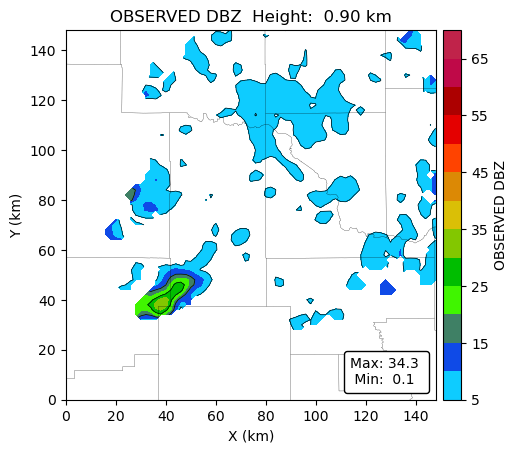

In [15]:
fig,ax=plt.subplots(1)
mfld = N.ma.masked_less_equal(f3d[5,:,:], 0.0)
label = "OBSERVED DBZ"
PLOT_ONE(mfld, x2d, y2d, map, clevels=clevels, height=state.zc[5], label = label, ax = ax, \
       counties=True, cmap=ctables.REF_default, zoom = zoom)

In [55]:
ob_file=None
cref=True

t0 = timer()

# These values are set in the experiment dictionary created at the begining of the run

hradius = state.experiment['ADD_NOISE']['hradius']
vradius = state.experiment['ADD_NOISE']['vradius']
xoffset = state.experiment['xoffset']
yoffset = state.experiment['yoffset']
glat    = state.experiment['lat0']
glon    = state.experiment['lon0']

# if ob_file == None, use experiment radar file

if ob_file == None:
    ob_file = state.experiment['radar_obs']

ob_f = pyDart.pyDART()
ob_f.file(ob_file)

# look for reflectivity +/- 2.5 min 

analysis_time = state.datetime[0]
dt            = datetime.timedelta(0,300)
begin         = analysis_time - dt/2
ending        = analysis_time + dt/2

print("\n ==> ens_GRID_REFL: Using pyDart to search with begin time of: ", begin.strftime("%Y-%m-%d %H:%M:%S"))
print("\n ==> ens_GRID_REFL: Using pyDart to search with end   time of: ", ending.strftime("%Y-%m-%d %H:%M:%S"))

ob_f.search(start=begin.timetuple()[:6], end=ending.timetuple()[:6], condition = '(kind == 12) & (value > 0.) & (z < 10000.)')

# number of observations, if there are none, stop program, something is wrong

if len(ob_f.index) >= 50:
    print("\n  ==> ens_GRID_REFL:  Total number of obs found at search time: %s \n" % len(ob_f.index))
else:
    print("\n  ==> ens_GRID_REFL:  Insufficient number of obs (<=50) found at search time:  %d obs \n" % (len(ob_f.index)))
    #return 'None'

# using the search index generated from above, obtain the location, data, and type

odata = ob_f.get_data()

data    = odata['value'][:]
lats    = odata['lat'][:]
lons    = odata['lon'][:]
hgts    = odata['height'][:]

print("\n ==> ens_GRID_REFL: Number of points found from initial search:      %d" % (data.size))

# The coordinate system here is based on the grid lat0/lon0/hgt0, and the offset grid stored in fstate
#     ens stores the x/y grid in grid-internal coordinates

map      = mymap(fstate.xc, fstate.yc, glat, glon)
xob, yob = map(lons, lats)
xob, yob = xob+xoffset, yob+yoffset

# The coordinate system here is based on the grid lat0/lon0/hgt0, and the offset grid stored in fstate
#     ens stores the x/y grid in grid-internal coordinates

# sw_lat, sw_lon = dxy_2_dll(fstate.xc.min(), fstate.yc.min(), glat, glon, degrees=True)
# ne_lat, ne_lon = dxy_2_dll(fstate.xc.max(), fstate.yc.max(), glat, glon, degrees=True)

# p1 = Proj(proj='lcc', ellps='WGS84', datum='WGS84', lat_1=_truelat1, lat_2=_truelat2, \
#                        lat_0=0.5*(ne_lat+sw_lat), lon_0=0.5*(ne_lon+sw_lon))
                     
# xob, yob = p1(lons, lats, errchk = True)
# xob, yob = xob+xoffset, yob+yoffset

print(" Information about where the obs are relative to the grid...")
print("X-GRID MIN: %4.1f  X-OB MIN:  %4.1f  X-OB MAX:  %4.1f  X-GRID MAX:  %4.1f" % \
      (0.001*fstate.xc.min(), 0.001*xob.min(),  0.001*xob.max(), 0.001*fstate.xc.max()))
print("Y-GRID MIN: %4.1f  Y-OB MIN:  %4.1f  Y-OB MAX:  %4.1f  Y-GRID MAX:  %4.1f" % \
      (0.001*fstate.yc.min(), 0.001*yob.min(),  0.001*yob.max(), 0.001*fstate.yc.max()))
print("Z-GRID MIN: %4.1f  Z-OB MIN:  %4.1f  Z-OB MAX:  %4.1f  Z-GRID MAX:  %4.1f" % \
      (0.001*fstate.zc.min(), 0.001*hgts.min(),  0.001*hgts.max(), 0.001*fstate.zc.max()))

# Create obs list for KDTree query...

xyz_obs  = N.vstack((hgts,yob,xob))
obs_list = list(xyz_obs.transpose())

# If needed, here is some fake data for testing code

# xob, yob, hgts = [xoffset+0.5*(fstate.xc.max()-fstate.xc.min())], [yoffset+0.5*(fstate.yc.max()-fstate.yc.min())], [2000.]
# xyz_obs  = N.vstack((hgts,yob,xob))
# obs_list = list(xyz_obs.transpose())
# data = 50.*N.ones((1,))   # single point of 50 dbz
# print(data, obs_list)

# Create 3D grid arrays for KDTree

y_array, z_array, x_array = N.meshgrid(fstate.yc, fstate.zc, fstate.xc)
xyz_grid = N.dstack([z_array.ravel(),y_array.ravel(),x_array.ravel()])[0]

# Use cKDTree to create fast indexing for 3D grid....

mytree = scipy.spatial.cKDTree(xyz_grid)
distance, indices1D = mytree.query(obs_list)

# these are the integer indices that you now pass into the fortran routine. They
# are the un-raveled 3D index locations nearest the observation point in the 3D array

kk,jj,ii = N.unravel_index(indices1D, (len(fstate.zc), len(fstate.yc), len(fstate.xc)))

# for n in N.arange(data.size):
#     print("obs#: %d  Zobs:  %8.1f  Zarray:  %8.1f" % (n, xyz_obs[0,n], z_array[kk[n],jj[n],ii[n]]))
#     print("obs#: %d  Yobs:  %8.1f  Yarray:  %8.1f" % (n, xyz_obs[1,n], y_array[kk[n],jj[n],ii[n]]))
#     print("obs#: %d  Xobs:  %8.1f  Xarray:  %8.1f\n" % (n, xyz_obs[2,n], x_array[kk[n],jj[n],ii[n]]))

# Call the fortran routine that grids the dbz data

dbz3d = obs_2_grid3d(data, xob, yob, hgts, x_array, y_array, z_array, ii, jj, kk, 4000., 2000., 0.0)

print("\n ==> ens_GRID_REFL: 3D gridded DBZ:   Max:  %4.1f   Min:  %4.1f" % (dbz3d.max(), dbz3d.min()))

# Create composite reflectivity, and then replicate it into a 3D array

dbz2d = N.zeros((1,))

if cref:

    dbz2d = dbz3d.max(axis=0)

for k in N.arange(state.nz):
    dbz3d[k] = dbz2d
  
print("\n ==> ens_GRID_REFL: 2D composite DBZ requested   Max:  %4.1f   Min:  %4.1f" % (dbz2d.max(), dbz2d.min()))


 ==> ens_GRID_REFL: Using pyDart to search with begin time of:  2003-05-08 20:57:30

 ==> ens_GRID_REFL: Using pyDart to search with end   time of:  2003-05-08 21:02:30
  pyDART.search:  no variable supplied....all vars dumped
  pyDART.search:  Start datetime:  2003-05-08 20:57:30
  pyDART.search:  End datetime:  2003-05-08 20:57:30

  pyDART file is version:  pyDART_file_version_2.3 
  \/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/

  PyDART SEARCH START TIME  2003-05-08 20:57:30  /  UTIME_START: 1052427450
  PyDART SEARCH END   TIME  2003-05-08 21:02:30  /  UTIME_END:   1052427750
  PyDART converted utimes: 2003-05-08 20:57:30

  PyDART SEARCH CONDITION IS: (1052427450 <= utime) & (utime < 1052427750) & (kind == 12) & (value > 0.) & (z < 10000.)

  ==> ens_GRID_REFL:  Total number of obs found at search time: 4576 


  pyDART file is version:  pyDART_file_version_2.3 
  \/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/


 ==> ens_GRID_REFL: Number of points foun

In [68]:
def PLOT_ONE(mfld, x2d, y2d, map, cint=None, height=0., label = None, ax=None, counties=None, \
             cmap = None, clevels = [], **kwargs):
#
#===============================================================================
  
  if cint == None and len(clevels) > 0:
    myclevels = clevels
  else:
    myclevels = nice_clevels(mfld.min(), mfld.max(), outside=True, cint=cint, **kwargs)[3]
     
  if cmap == None:
    cmap = ens_default_cmap

  if "zoom" in kwargs:
    zoom = kwargs["zoom"]
  else:
    zoom = None

  clvls = myclevels[ myclevels != 0.0 ] 
    
  plot = map.contourf(x2d, y2d, mfld, myclevels, ax = ax, cmap=cmap)
  cbar = map.colorbar(plot, ax=ax)
  plot = map.contour(x2d, y2d, mfld, clvls[::2], colors='k', linewidths=0.5, ax=ax)
  cbar.set_label('%s' % label[0:3])
  ax.tick_params(axis='both', which='major', labelsize=10)
  ax.tick_params(axis='both', which='minor', labelsize=8)
  ax.xaxis.set_major_formatter(ticker.FuncFormatter(ens.mtokm))
  ax.yaxis.set_major_formatter(ticker.FuncFormatter(ens.mtokm))
  ax.set_xlabel("%s" % ('X (km)'))
  ax.set_ylabel("%s" % ('Y (km)'))
  if zoom:
      ax.set_xlim(1000.*zoom[0],1000.*zoom[1])
      ax.set_ylim(1000.*zoom[2],1000.*zoom[3])

  if label:
    cbar.set_label(label)
    title = ("%s  Height:  %4.2f km" % (label, height/1000.))
    ax.set_title(title, fontsize=12)
    
  if counties:
    ens.mymap_draw_details(map, shape_env=None, ax=ax)
  
  at = AnchoredText("Max: %4.1f \n Min: %4.1f" % (mfld.max(),mfld.min()), loc=4, prop=dict(size=10), frameon=True,)
  at.patch.set_boxstyle("round,pad=0.,rounding_size=0.2")
  ax.add_artist(at)

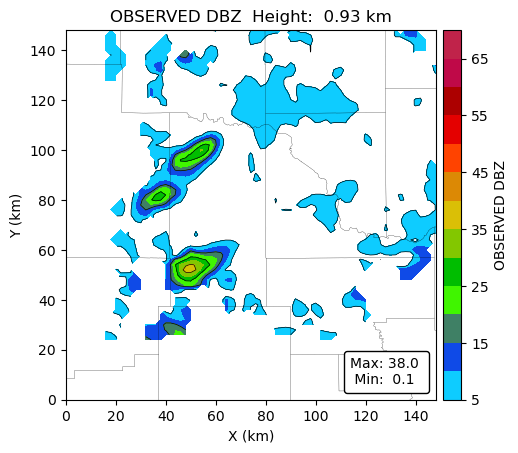

In [69]:
fig,ax=plt.subplots()

label = "OBSERVED DBZ"
PLOT_ONE(mfld, x2d, y2d, map, clevels=clevels, height=state.zc[5], label = label, ax = ax, \
       counties=True, cmap=ctables.REF_default, zoom = zoom)

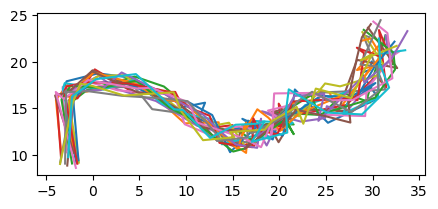

In [15]:
t=0
fig=plt.figure(figsize=(5,5))
ax = plt.gca()
ax.set_aspect('equal')
for mem in np.arange(1,21,1):
    #try:
    cm1 = xr.open_dataset(f'/work/jessica.mcdonald/CM1_LETKF_2025/RUN_LETKF/member{mem:03d}/cm1out_rst_{t:06d}.nc')
   
    
    plt.plot(cm1.ua[:20,0,-1],cm1.va[:20,0,-1], )
    cm1.close()
    

In [19]:
%tb
myDTstring = '2003,05,08,20,40,00'

with open('/work/jessica.mcdonald/CM1_LETKF_2025/RUN_LETKF/RUN_LETKF.exp', 'rb') as f:
    exper = json.load(f)

    
files, myDT = ens_FindRestartFiles(exper, myDTstring, ret_exp=False,)

SystemExit: -1


 ==> FindRestartFiles: Date and time supplied is 2003_05_08 20:40:00

 ==> FindRestartFile:  Found time 0 in file:  /work/jessica.mcdonald/CM1_LETKF_2025/RUN_LETKF/member001/cm1rst_000000.nc


In [20]:
files

['/work/jessica.mcdonald/CM1_LETKF_2025/RUN_LETKF/member001/cm1rst_000000.nc',
 '/work/jessica.mcdonald/CM1_LETKF_2025/RUN_LETKF/member002/cm1rst_000000.nc']

In [ ]:
output_basename = 'cm1' #cm1out #namelist['param9']['output_basename']
#namelist['param2']['irst']             = 1
print(FindRestartFile(experiment['fcst_members'][0],output_basename,start_time)

In [25]:
mem=1
for t in np.arange(1, 11, 1):# [0,1,2]:#np.arange(1, 22,3):#[0:10]: # time = (t-1)*10
    #try:
    cm1 = xr.open_dataset(f'/work/jessica.mcdonald/CM1_LETKF_2025/RUN_LETKF/member{mem:03d}/cm1rst_{t:06d}.nc',decode_timedelta=True)
    print(cm1.attrs['hour']*100+cm1.attrs['minute'])
    # fig=plt.figure(figsize=(5,5))
    # ax = plt.gca()
    # ax.set_aspect('equal')
    # im=ax.contour(cm1.xh, cm1.yh, cm1.dbz[:,:,:].max(axis=0), levels=np.arange(0, 75, 2), colors='k', linewidths=.5)
    # im=ax.contourf(cm1.xh, cm1.yh, cm1.theta[4,:,:]- cm1.theta[4,-1,-1], cmap='RdBu_r', levels=np.arange(-5, 5.1, .1))#, levels=np.arange(0, 75, 2), cmap='jet')
    
    # plt.colorbar(im)
    # plt.show()
    
    cm1.close()
   


2040
2040
2040
2040
2040
2040
2040
2040
2040
2040


In [37]:
cm1

<xarray.Dataset> Size: 36MB
Dimensions:       (time: 1, ni: 75, nip1: 76, nj: 75, njp1: 76, nk: 51,
                   nkp1: 52, nbudget: 10, numq: 16)
Coordinates:
  * time          (time) timedelta64[ns] 8B 00:50:00
Dimensions without coordinates: ni, nip1, nj, njp1, nk, nkp1, nbudget, numq
Data variables: (12/122)
    xh            (ni) float32 300B ...
    xf            (nip1) float32 304B ...
    yh            (nj) float32 300B ...
    yf            (njp1) float32 304B ...
    zh            (nk) float32 204B ...
    zf            (nkp1) float32 208B ...
    ...            ...
    radbcw        (time, nk, nj) float32 15kB ...
    radbce        (time, nk, nj) float32 15kB ...
    radbcs        (time, nk, ni) float32 15kB ...
    radbcn        (time, nk, ni) float32 15kB ...
    theta         (time, nk, nj, ni) float32 1MB ...
    dbz           (time, nk, nj, ni) float32 1MB ...
Attributes: (12/62)
    nx:          75
    ny:          75
    nz:          51
    imoist:      1
    sgsmodel:    1
    tconfig:     1
    ...          ...
    cgt1:        1.8750015
    cgt2:        -1.2500014
    cgt3:        0.37499988
    dgt1:        2.0000038
    dgt2:        -3.0000038
    dgt3:        1.0

In [7]:
cm1 = xr.open_dataset('/work/jessica.mcdonald/CM1_LETKF_2025/RUN_LETKF/member001/cm1out_000001.nc')
cm1.time

/tmp/ipykernel_1827008/3444682860.py:1: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  cm1 = xr.open_dataset('/work/jessica.mcdonald/CM1_LETKF_2025/RUN_LETKF/member001/cm1out_000001.nc')


<xarray.DataArray 'time' (time: 1)> Size: 8B
array([0], dtype='timedelta64[ns]')
Coordinates:
  * time     (time) timedelta64[ns] 8B 00:00:00
Attributes:
    long_name:  time since beginning of simulation
    axis:       T

In [8]:
mem=2
t=6
cm1 = xr.open_dataset(f'/work/jessica.mcdonald/CM1_LETKF_2025/RUN_LETKF/member{mem:03d}/cm1rst_{t:06d}.nc',decode_timedelta=True)
prior = xr.open_dataset(f'/work/jessica.mcdonald/CM1_LETKF_2025/RUN_LETKF/member{mem:03d}/cm1_prior_{t:06d}.nc',decode_timedelta=True)

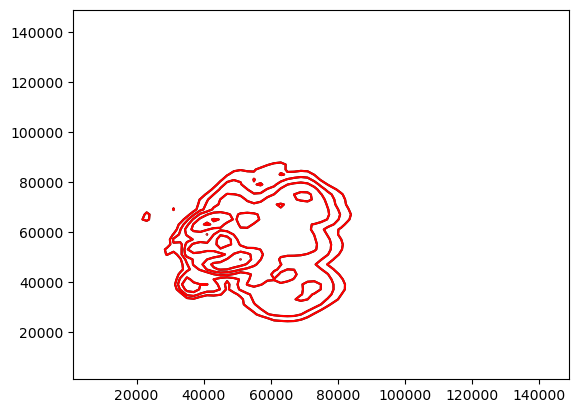

In [5]:
plt.contour(cm1.xh, cm1.yh, cm1.dbz[0,:].max(axis=0), levels=np.arange(10, 70, 10), colors='k')

plt.contour(cm1.xh, cm1.yh, prior.dbz[0,:].max(axis=0), levels=np.arange(10, 70, 10), colors='r')

In [11]:
f= ncdf.Dataset(f'/work/jessica.mcdonald/CM1_LETKF_2025/RUN_LETKF/member{mem:03d}/cm1rst_{t:06d}.nc')
f['time']

<class 'netCDF4.Variable'>
float32 time(time)
    long_name: time since beginning of simulation
    units: seconds
unlimited dimensions: time
current shape = (1,)
filling on, default _FillValue of 9.969209968386869e+36 used

/tmp/ipykernel_3199192/2603253127.py:4: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig=plt.figure()


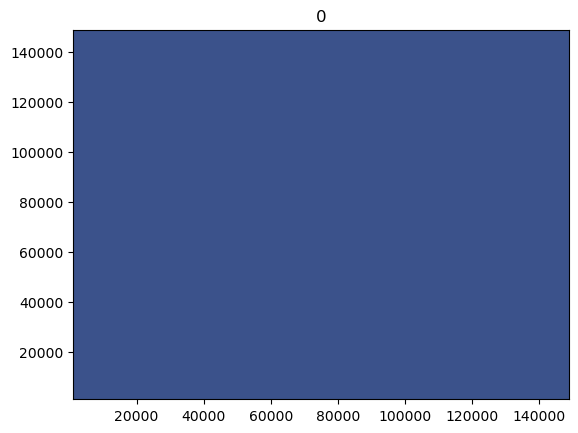

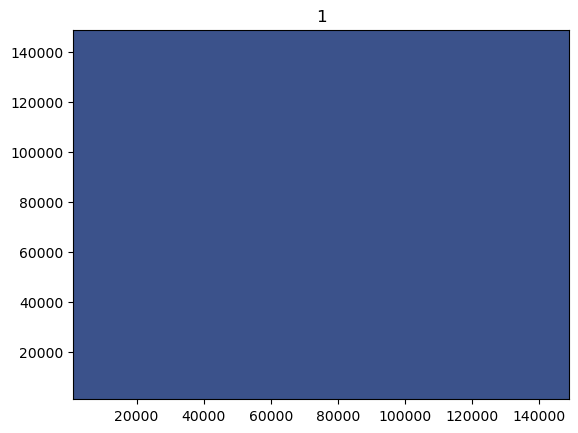

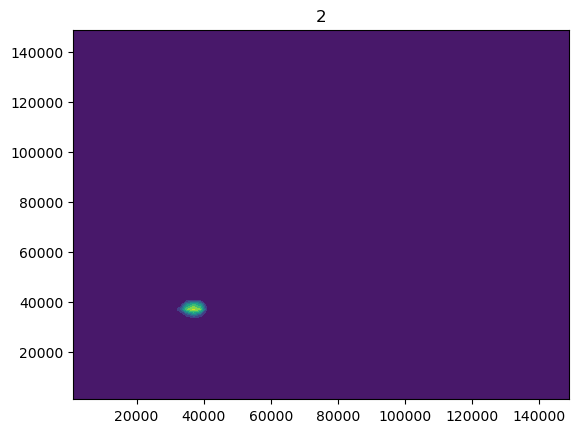

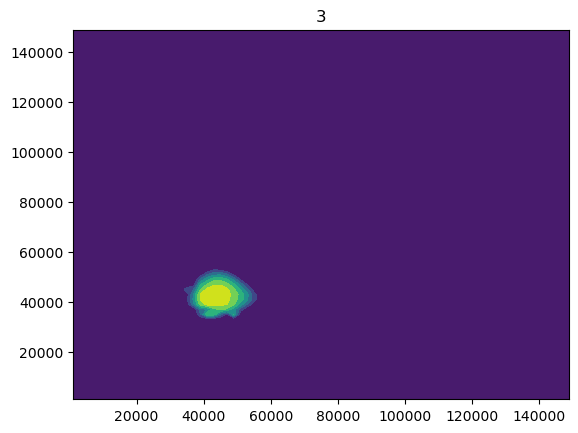

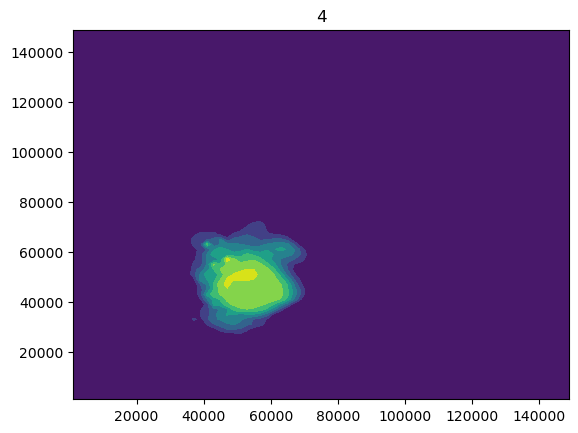

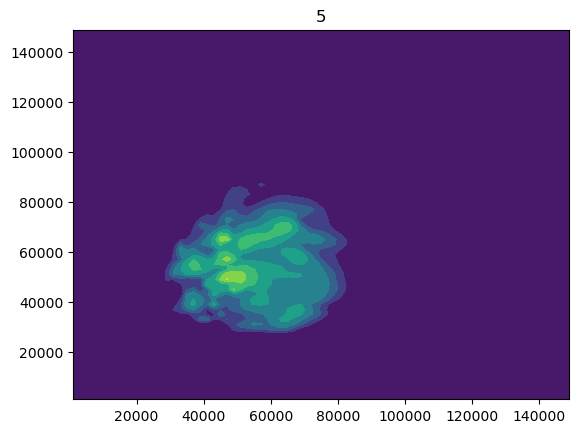

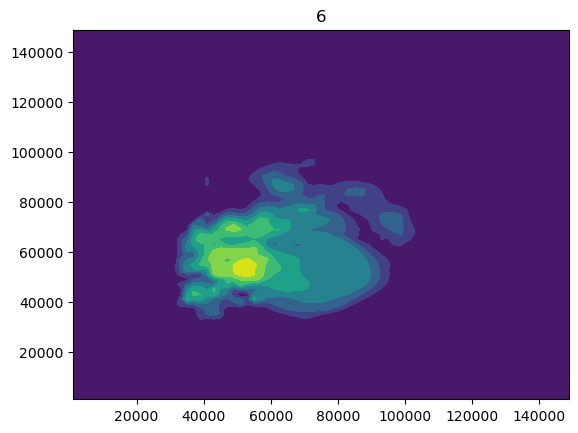

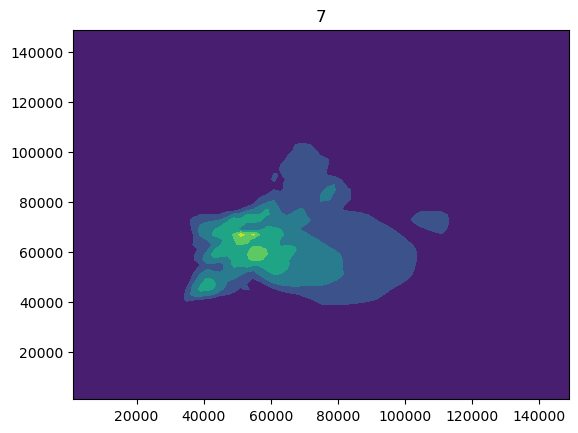

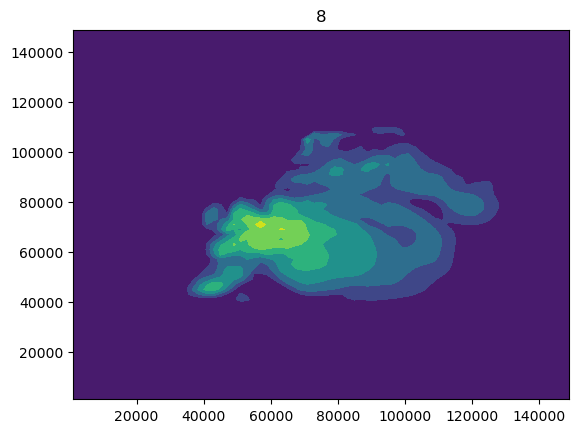

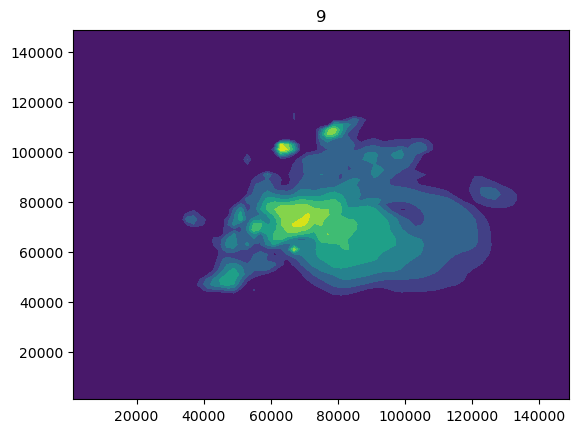

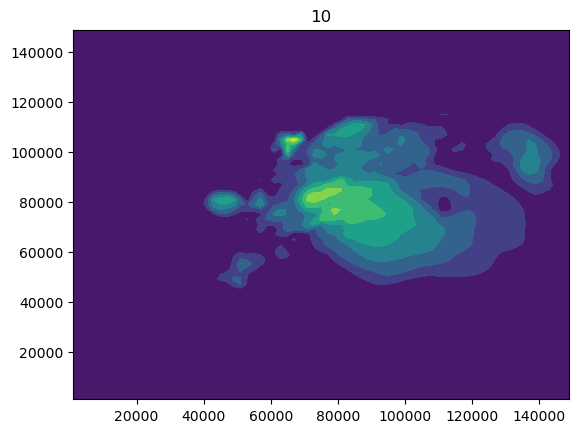

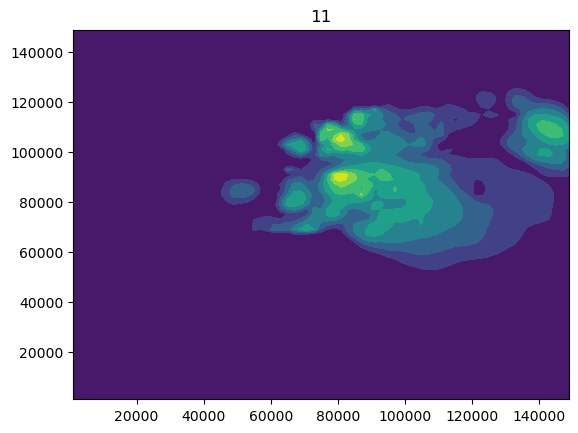

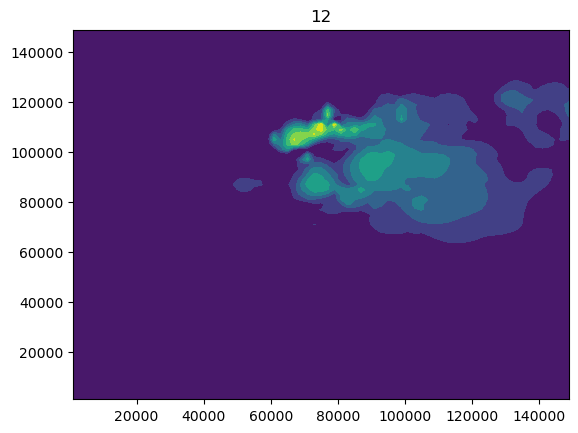

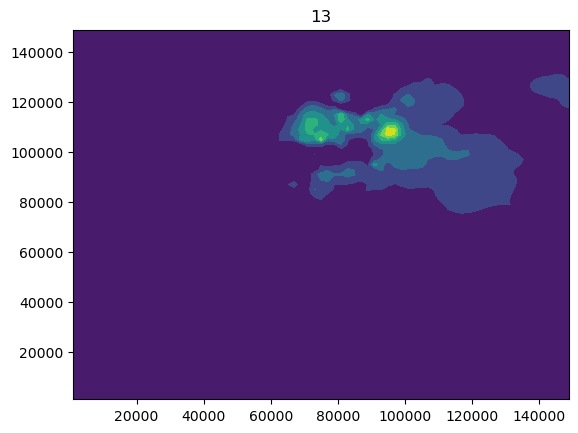

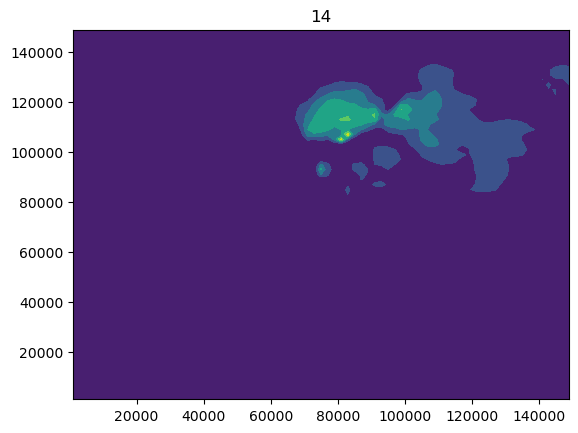

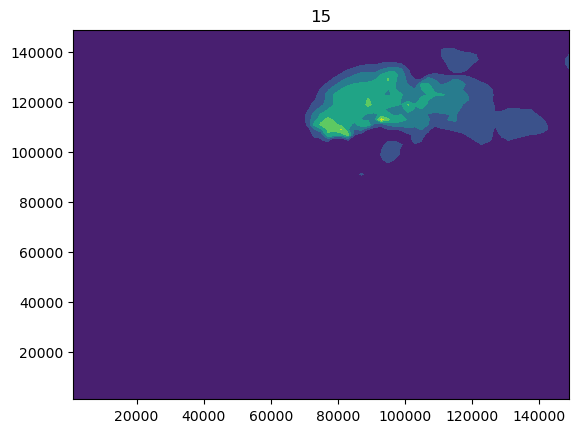

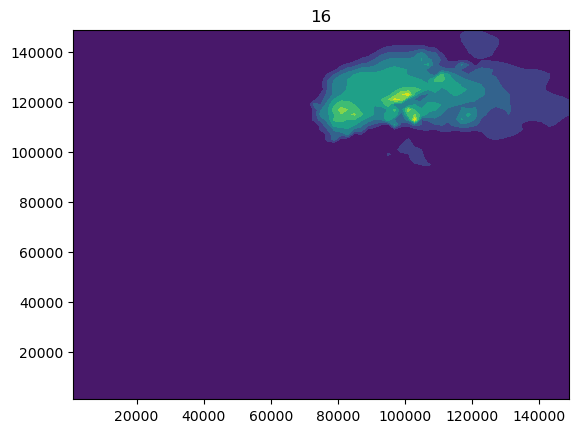

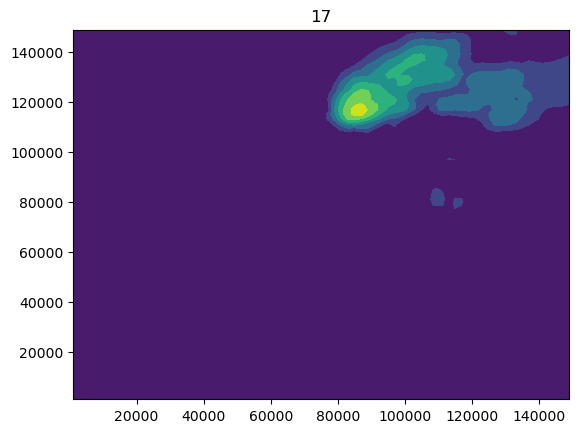

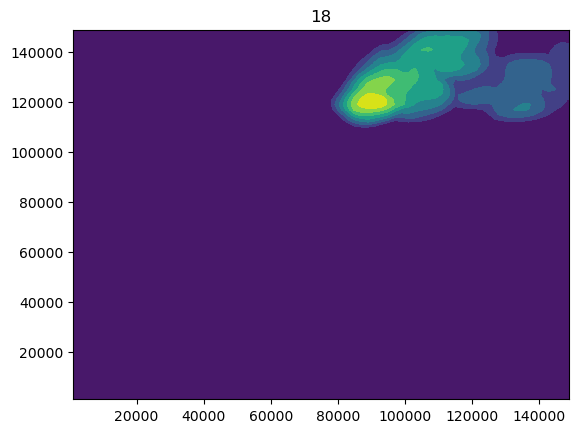

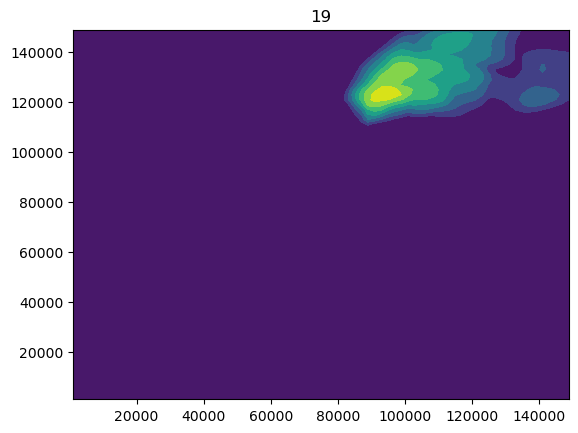

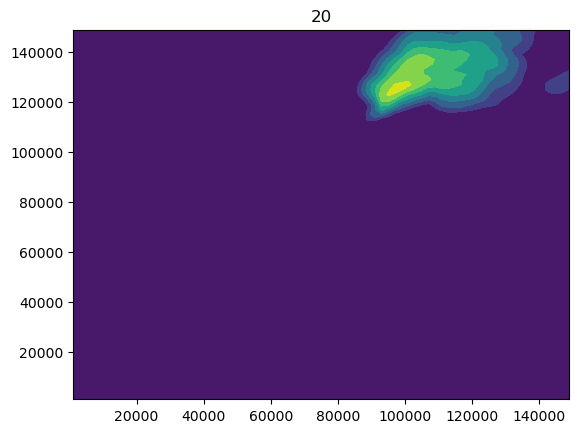

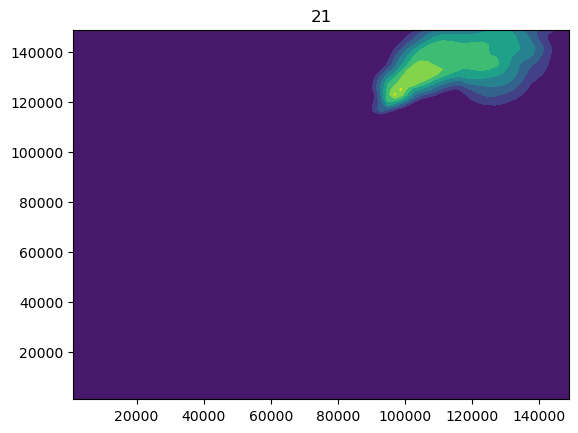

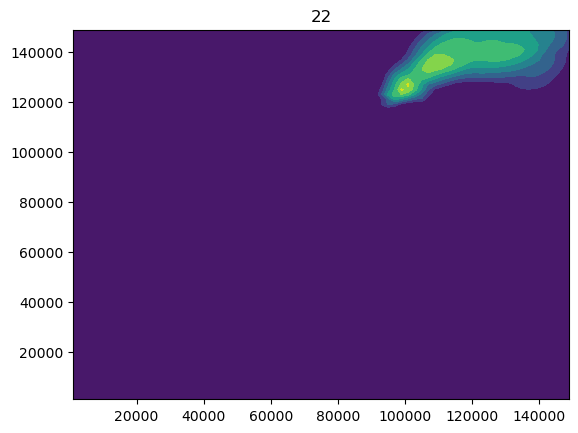

In [4]:

mem=1
for t in np.arange(0, 23):
    cm1 = xr.open_dataset(f'/work/jessica.mcdonald/CM1_LETKF_2025/RUN_LETKF/member{mem:03d}/cm1rst_{t:06d}.nc',decode_timedelta=True)
    fig=plt.figure()
    plt.title(t)
    plt.contourf(cm1.xh, cm1.yh, cm1.dbz[0,:].max(axis=0))
#print(cm1.time.astype('timedelta64[s]')[0].values)

In [20]:
print(cm1.time.astype('timedelta64[s]')[0].values)

900 seconds


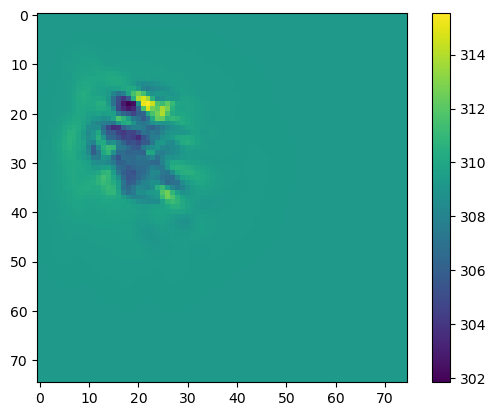

In [6]:
plt.imshow(cm1.theta[0,6,:,:])
plt.colorbar()

In [5]:
#import netCDF4 as ncdf

mem=1
t=4
file=f'/work/jessica.mcdonald/CM1_LETKF_2025/RUN_LETKF/member{mem:03d}/cm1rst_{t:06d}.nc'

f = ncdf.Dataset(file, "r")
f_time = f.variables['time'][0]

print(f.variables)
f.close()

{'time': <class 'netCDF4._netCDF4.Variable'>
float32 time(time)
    long_name: time since beginning of simulation
    units: seconds
unlimited dimensions: time
current shape = (1,)
filling on, default _FillValue of 9.969209968386869e+36 used, 'xh': <class 'netCDF4._netCDF4.Variable'>
float32 xh(ni)
    long_name: west-east location of scalar grid points
    units: m
unlimited dimensions: 
current shape = (75,)
filling on, default _FillValue of 9.969209968386869e+36 used, 'xf': <class 'netCDF4._netCDF4.Variable'>
float32 xf(nip1)
    long_name: west-east location of staggered u grid points
    units: m
unlimited dimensions: 
current shape = (76,)
filling on, default _FillValue of 9.969209968386869e+36 used, 'yh': <class 'netCDF4._netCDF4.Variable'>
float32 yh(nj)
    long_name: south-north location of scalar grid points
    units: m
unlimited dimensions: 
current shape = (75,)
filling on, default _FillValue of 9.969209968386869e+36 used, 'yf': <class 'netCDF4._netCDF4.Variable'>
float32

In [13]:
f.variables

{'time': <class 'netCDF4._netCDF4.Variable'>
 float32 time(time)
     long_name: time since beginning of simulation
     units: seconds
 unlimited dimensions: time
 current shape = (1,)
 filling on, default _FillValue of 9.969209968386869e+36 used,
 'xh': <class 'netCDF4._netCDF4.Variable'>
 float32 xh(ni)
     long_name: west-east location of scalar grid points
     units: m
 unlimited dimensions: 
 current shape = (75,)
 filling on, default _FillValue of 9.969209968386869e+36 used,
 'xf': <class 'netCDF4._netCDF4.Variable'>
 float32 xf(nip1)
     long_name: west-east location of staggered u grid points
     units: m
 unlimited dimensions: 
 current shape = (76,)
 filling on, default _FillValue of 9.969209968386869e+36 used,
 'yh': <class 'netCDF4._netCDF4.Variable'>
 float32 yh(nj)
     long_name: south-north location of scalar grid points
     units: m
 unlimited dimensions: 
 current shape = (75,)
 filling on, default _FillValue of 9.969209968386869e+36 used,
 'yf': <class 'netCDF4

In [12]:
print(f.variables['time'][0])
print(f.variables['time'])

1200.0
<class 'netCDF4._netCDF4.Variable'>
float32 time(time)
    long_name: time since beginning of simulation
    units: seconds
unlimited dimensions: time
current shape = (1,)
filling on, default _FillValue of 9.969209968386869e+36 used


In [ ]:
import time
i = 5
while i < 10:
    time.sleep(600)
    print (i)
    i = 5

In [4]:
t=5
cm1 = xr.open_dataset(f'/work/jessica.mcdonald/CM1_LETKF_2025/RUN_LETKF/member001/cm1rst_{t:06d}.nc')


# t=0
# cm1 = xr.open_dataset(f'/work/jessica.mcdonald/RUN_LETKF/member001/cm1out_rst_{t:06d}.nc')

/tmp/ipykernel_2485030/3772562344.py:2: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  cm1 = xr.open_dataset(f'/work/jessica.mcdonald/CM1_LETKF_2025/RUN_LETKF/member001/cm1rst_{t:06d}.nc')


In [45]:
cm1

<xarray.Dataset> Size: 44MB
Dimensions:     (time: 1, ni: 75, nip1: 76, nj: 75, njp1: 76, nk: 51, nkp1: 52,
                 nbudget: 10, numq: 16)
Coordinates:
  * time        (time) datetime64[ns] 8B 2003-05-08T21:40:00
Dimensions without coordinates: ni, nip1, nj, njp1, nk, nkp1, nbudget, numq
Data variables: (12/82)
    xh          (ni) float32 300B ...
    xf          (nip1) float32 304B ...
    yh          (nj) float32 300B ...
    yf          (njp1) float32 304B ...
    zh          (nk) float32 204B ...
    zf          (nkp1) float32 208B ...
    ...          ...
    prs0        (nk, nj, ni) float32 1MB ...
    pi0         (nk, nj, ni) float32 1MB ...
    rho0        (nk, nj, ni) float32 1MB ...
    qv0         (nk, nj, ni) float32 1MB ...
    u0          (nk, nj, nip1) float32 1MB ...
    v0          (nk, njp1, ni) float32 1MB ...

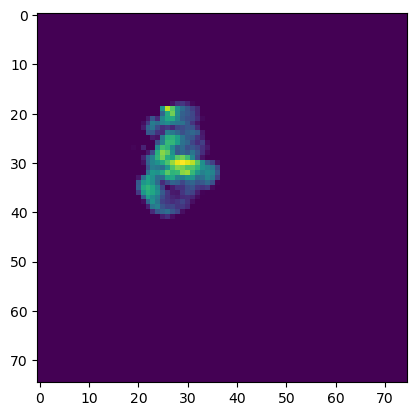

In [6]:
plt.imshow(cm1.dbz[0,5,:,:])

In [1]:
'met_em.d01.2024-05-08_15_00_00.nc' == 'met_em.d01.2024-05-08_15_00_00.nc'

True

In [10]:
temp = xr.open_dataset('/home/jessica.mcdonald/wrf_tests/WRF/run/wrfbdy_d01')
print(temp.Times.values)
temp.close()

[b'2024-05-08_15:00:00' b'2024-05-08_16:00:00' b'2024-05-08_17:00:00'
 b'2024-05-08_18:00:00' b'2024-05-08_19:00:00' b'2024-05-08_20:00:00'
 b'2024-05-08_21:00:00' b'2024-05-08_22:00:00' b'2024-05-08_23:00:00'
 b'2024-05-09_00:00:00' b'2024-05-09_01:00:00' b'2024-05-09_02:00:00'
 b'2024-05-09_03:00:00']


In [1]:
#!/usr/bin/env python
import sys
import os
import numpy as N
import datetime as DT 
from netCDF4 import *
import pyDart
import ens 
import glob
from optparse import OptionParser
from multiprocessing import Pool
from time import time as timer
from nc_prior_file import *
from assim_util import *
import state_vector as state
import json

In [3]:
%tb
missing = -999.
diag = True

# Stuff to set observation std deviation in filter

_default_obs_error = {11: ["VR", 2.0], 12:["DBZ", 5.0]}
  
#-----------------------------------------------------------------------------------------------------------------------------------
# Main program

#if __name__ == "__main__":
me=True
if me == True:

  stime = timer()
  now = DT.datetime.now()

  print("\n  ----------------------------------------------------------------------")
  print("\n                BEGIN PROGRAM ComputeHx                                 ")
  print("\n    WALLCLOCK START TIME:  %s \n" % now.strftime("%Y-%m-%d %H:%M")  )
  print("\n  ----------------------------------------------------------------------")
  
#-----------------------------------------------
# Timers for the code...

  timeUpdate  = myTimer(name = "Update")
  timePrint   = myTimer(name = "Print")
  timeIO      = myTimer(name = "I/O")
  timeMain    = myTimer(name = "MAIN Program", minutes=True)
  timeHxF     = myTimer(name = "HxF")
  
# Time the ESRF analysis

  timeMain.start()

#   python computeHx.py --exper RUN_LETKF/RUN_LETKF.exp --time 2003,05,08,21,00,00 -o Obs/obs_seq_8may03_2km.h5 --window 300 --init

# # Parse input command options

#   parser = OptionParser()
#   parser.add_option("-o", "--obs",        dest="obs",       type="string",  help = "Observation file")
#   parser.add_option("-t", "--time",       dest="time",      type="string",  help = "Time of prior calculations: 2008,05,8,22,10,00")
#   parser.add_option("-e", "--exper",      dest="exper",     type="string",  help = "experiment run file created to store database info")
#   parser.add_option(      "--nthreads",   dest="nthreads",  type="int",     help = "Number of threads for LETKF computation")
#   parser.add_option(      "--window",     dest="window",    type="int",     help = "Width in seconds of Hx window")
#   parser.add_option(      "--init",       dest="init",      default=False,  help = "Create new prior file", action="store_true")
#   parser.add_option(      "--final",      dest="final",     default=False,  help = "Movie prior file to new DT-labeled file", action="store_true")
#   parser.add_option(      "--obserr",     dest="obserr",    default=None,   type = "string", nargs=4, help = "Set observational errors, e.g., VR 3.0 DBZ 7.5")
  
#   (options, args) = parser.parse_args()
  
#-------------------------------------------------------------------------------  
# Get experiment file

  with open('RUN_LETKF/RUN_LETKF.exp', 'rb') as p:
        exper = json.load(p)

  # if options.exper == None:
  #   print("\n --> ComputeHx:  No experiment's run filename specified, exiting....\n")
  #   parser.print_help()
  #   sys.exit(-1)
  # else:
  #   with open(options.exper, 'rb') as p:
  #       exper = json.load(p)
        
# get path for file creation and location

  path = exper['base_path']
  
#-------------------------------------------------------------------------------
# Get the time stamp
  time = "2003,05,08,21,00,00".split(",")  
    
  # if options.time == None:
  #   print("\n --> ComputeHx:  No analysis time specified, exiting....\n")
  #   parser.print_help()
  #   sys.exit(-1)
  # else:
  #   time = options.time.split(",")

#-------------------------------------------------------------------------------
# Obs error
  obs_error = exper['DA_PARAMS']['obs_errors']
  # if options.obserr == None:
  #   obs_error = exper['DA_PARAMS']['obs_errors']
  #   print("\n --> ComputeHx:  using the obs errors from the EXPER file:  %s" % obs_error)
  # else:
  #   print("\n --> ComputeHx:  using the obs errors from command line")
  #   obs_error = _default_obs_error
  #   for key in obs_error.keys():
  #     for n, item in enumerate(options.obserr):
  #       if item == obs_error[key][0]:
  #          print("\n --> ComputeHx:  Changing %s observational error to:  %s" % (obs_error[key][0],options.obserr[n+1]))
  #          obs_error[key][1] = float(options.obserr[n+1])

#-------------------------------------------------------------------------------
# Set up window to look for
  window = int(exper['DA_PARAMS']['assim_window'])
  # if options.window == None:
  #   window = int(exper['DA_PARAMS']['assim_window'])
  #   print("\n --> ComputeHx:  using the window from the EXPER file:  +/- %d secs" % (window/2))
  # else:
  #   window = int(options.window)
  #   print("\n --> ComputeHx:  using the window from the command line:  +/- %d secs" % (window/2))

#-------------------------------------------------------------------------------    
# Observation file
  obs_file = 'Obs/obs_seq_8may03_2km.h5'

  # if options.obs == None:
  #   obs_file = exper['radar_obs']
  #   print("\n --> ComputeHx:  using the observation file from the EXPER file:  %s" % obs_file)
  # else:
  #   obs_file = options.obs
  #   print("\n --> ComputeHx:  using the observation file from the command line:  %s" % obs_file)

#-------------------------------------------------------------------------------    
# Init flag creates a new file
  init=True 
  # if options.init:
  #   init = options.init
  # else:
  #   init = False

#-------------------------------------------------------------------------------    
# Final flag moves prior file to Prior_DateTime.nc
  final=False
  # if options.final:
  #   final = options.final
  # else:
  #   final = False




#-------------------------------------------------------------------------------    
# Need this value for 

  outlier = exper['DA_PARAMS']['outlier']
  print("\n --> ComputeHx: obs outlier is from EXPER file:  %d" % outlier)

   
#################################################################################################
# Read and search the observation file for each chunk of time...

  timeHxF.start()
  
  ob_f = pyDart.pyDART()
  ob_f.file(obs_file)   
  
# Initialize a bunch of containers, they get converted to numpy arrays below

  lat     = N.empty((0))
  lon     = N.empty((0))
  dates   = N.empty((0))
  value   = N.empty((0))
  kind    = N.empty((0))
  height  = N.empty((0))
  elev    = N.empty((0))
  az      = N.empty((0))
  err_var = N.empty((0))
  idx     = N.empty((0))

  analysis_time = DT.datetime(int(time[0]),int(time[1]),int(time[2]),int(time[3]),int(time[4]),int(time[5]))
     
  print("\n --> ComputeHx:  Reading in model state for HxF at %s \n" %  (analysis_time.strftime("%Y-%m-%d %H:%M:%S")))
    
# read from history files

  timeIO.start()
    
  files = ens.FindRestartFiles(exper, analysis_time, ret_exp=False, ret_DT=False)

  state = ens.read_CM1_ens(files, exper, state_vector=state.Hxf, DateTime=analysis_time)   
  ens.ens_CM1_C2A(state)
  ens.ens_CM1_coords(state)

  timeIO.stop()
    
  Hxfm = N.empty((0,state.ne))  # need to init this here cause need size of ensemble
    
  g_lat_max = state.late[:].max()
  g_lat_min = state.late[:].min()
  g_lon_max = state.lone[:].max()
  g_lon_min = state.lone[:].min()
  g_alt_max = max(state.zc.data[:]) + state.hgt
  g_alt_min = min(state.zc.data[:]) + state.hgt
    
  calt = " & ( " + str(g_alt_min) + " < height < " + str(g_alt_max) + " ) "
  clat = "( " + str(g_lat_min) + " < lat < " + str(g_lat_max) + " ) "
  condition = clat + " & ( " + str(g_lon_min) + " < lon < " + str(g_lon_max) + " ) "

  dt     = DT.timedelta(0,int(window/2))
  begin  = analysis_time - dt
  ending = analysis_time + dt
    
  print("\n --> ComputeHx:  Using pyDart to search with condition: " + condition  )
  print("\n --> ComputeHx:  Using pyDart to search with begin time of: ", begin.timetuple()[:6])
  print("\n --> ComputeHx:  Using pyDart to search with end   time of: ", ending.timetuple()[:6])
    
# I used to try and limit lat/lon of search, but gave up 

# ob_f.search(start=begin.timetuple()[:6], end=ending.timetuple()[:6], condition=condition)

  ob_f.search(start=begin.timetuple()[:6], end=ending.timetuple()[:6])

# number of observations, if there are none, kick out of the loop...
  
  if len(ob_f.index) > 0:
    print("\n --> ComputeHx:  Total number of obs found at search time: %s \n" % len(ob_f.index))
  else:
    print("\n --> ComputeHx:  No obs found at search time:  %s exiting......\n" % (analysis_time))
    sys.exit(0)
  
# using the search index generated from above, obtain the location, data, and type

  subdata = ob_f.get_data()

# Compute Hxfs from 

  idx, Hxf, kind, lat, lon, height, elev, azimuth = ens.calcHx(state, 
                                                               subdata['kind'], 
                                                               subdata['lat'],                                         
                                                               subdata['lon'],
                                                               subdata['height'],
                                                               subdata['elevation'], subdata['azimuth'])
   
# At this point we have created all the Hxfs and so we can make sure we have enough obs to run

  if idx != None:

    nobs = N.size(idx) 

    print("\n --> ComputeHx:  Total number of obs found is: %d \n" % (nobs))

# retrieve these from pyTable

    err_var = N.append(err_var, subdata['error_var'][idx])   
    value   = N.append(value,   subdata['value'][idx])
    dates   = N.append(dates,   subdata['date'][idx])
  
  else:
    print("\n  >======================================================================<\n")   
    print("\n    ComputeHx: NOBS == 0:  NO HXF's were created - EXITING computeHx!!!  ")
    print("\n    ComputeHx:  NOBS == 0:  NO HXF's were created - EXITING computeHx!!! ")
    print("\n  >======================================================================<\n"   )
    sys.exit(0)
    
# Overide the file observation std deviations with either defaults at top of script or input parameters

  for key in obs_error.keys():
    print_once = True
    for n, item in enumerate(kind):
      if int(item) == int(key):
         err_var[n] = obs_error[key][1]**2.0
         if print_once:
           print("\n --> ComputeHx:  Changing %s observational error to:  %s" % (obs_error[key][0],obs_error[key][1]))
           print_once = False

# Here we choose to create a coordinate system of x/y's based from the SW corner (lat,lon) of model grid.
# The observations' new x/y's are then in the model's coordinate system relative to reference (lat,lon) of grid

  xs, ys = pyDart.dll_2_dxy(state.late[0], lat, state.lone[0], lon, degrees=True)
  zs     = height
  
  Hxfbar = N.average(Hxf,axis=1)
    
# We dont use this flag (is supposed to be a flag to tell one whether the obs is used for verification or assimilation, or thrown out)
  status = N.ones(nobs)
  
# WRITE OUT priors

# Here we create the Prior file if needed.  Note, the prior file may not be same datetime as current time
  if init:
    create_prior_file(state.ne)

  write_prior(state.ne, kind, value, dates, err_var, xs, ys, zs, Hxf, Hxfbar, lat, lon, elev, azimuth, status, outlier)
  
  if final:
    newPriorFile = os.path.join(path, "Prior_%s.nc" % analysis_time.strftime("%Y-%m-%d_%H:%M:%S"))
    os.rename("Prior.nc", newPriorFile)
  
  timeHxF.stop()
  
  timeIO.printit("--> ComputeHx:  Total time for ensemble I/O")
  
  timeHxF.printit("--> ComputeHx:  Time for searching ob table and computing priors")

  timeMain.stop()
  timeMain.printit("--> ComputeHx:  Total time in minutes")

# Print out Wallclock time for ComputeHx

  now = DT.datetime.now()

  print("\n  ----------------------------------------------------------------------")
  print("\n                END PROGRAM ComputeHx                                   ")
  print("\n      WALLCLOCK END TIME:  %s " % now.strftime("%Y-%m-%d %H:%M")     )
  print("\n  ----------------------------------------------------------------------\n")



SystemExit: 


  ----------------------------------------------------------------------

                BEGIN PROGRAM ComputeHx                                 

    WALLCLOCK START TIME:  2025-03-12 15:21 


  ----------------------------------------------------------------------

 --> ComputeHx: obs outlier is from EXPER file:  3

 --> ComputeHx:  Reading in model state for HxF at 2003-05-08 21:00:00 


 ==> FindRestartFiles: Date and time supplied is 2003_05_08 21:00:00

 ==> FindRestartFile:  Found time 1200 in file:  /work/jessica.mcdonald/CM1_LETKF_2025/RUN_LETKF/member001/cm1rst_000004.nc

 ==> READ_CM1_ENS: reading from time INDEX:  0
 ==> READ_CM1_ENS: reading from state TIME:  2003-05-08 21:00:00 


 READ_CM1_ENS ==> WARNING:  netCDF file: /work/jessica.mcdonald/CM1_LETKF_2025/RUN_LETKF/member001/cm1rst_000004.nc DOES NOT contain time index:  0 



SystemExit: 

In [3]:
#!/usr/bin/env python
import sys
import os
import numpy as N
import datetime as DT 
from netCDF4 import *
import pyDart
from pyDart import dll_2_dxy
import ens 
import glob
from optparse import OptionParser
from multiprocessing import Pool
from time import time as timer
from nc_prior_file import *
from assim_util import *
import state_vector as state
import pickle
import json
# Fortran functions
sys.path.append( "./fsrc" )
from fpython2 import fstate


In [ ]:
python letkf.py --exper RUN_LETKF/RUN_LETKF.exp --time 2003,05,08,21,00,00 --nthreads 1

In [11]:

#-------------------------------------------------------------------------------
# Default values 

_missing_value = 9900000000.
_time_units    = 'seconds since 1970-01-01 00:00:00'
_calendar      = 'standard'

debug  = False
_update_theta = 1
_variable_dbz_error = False

#-------------------------------------------------------------------------------
# Run parameters for the filter

obs_diag = {11: ["VR"], 12:["DBZ"]}

#-------------------------------------------------------------------------------
def getIndexEqual(field, value):
    return ( field == value )

#-------------------------------------------------------------------------------
def getIndexGT(field, value):
    return ( field > value )

#-------------------------------------------------------------------------------
def getIndexLT(field, value):
    return ( field < value )

########################################################################################################################
#
# Main program
me=True
if me==True:

  stime = timer()
  now = DT.datetime.now()

  print("----------------------------------------------------------------------\n")
  print("              BEGIN PROGRAM LETKF                                     \n ")
  print(("  WALLCLOCK START TIME:  %s \n" % now.strftime("%Y-%m-%d %H:%M")))  
  print("  --------------------------------------------------------------------\n")
  
# Create timers for the code...

  timeFilter   = myTimer(name = "Filter")
  timeIO       = myTimer(name = "I/O")
  timeMain     = myTimer(name = "Program")
  timeHxF      = myTimer(name = "HxF")
  
# Time the data assimilation

  timeMain.start()

#-------------------------------------------------------------------------------
# Parse input command options

#   parser = OptionParser()
#   parser.add_option("-f", "--file",      dest="file",     type="string", help = "Priors netCDF file")
#   parser.add_option("-t", "--time",      dest="time",     type="string", help = "Analysis time in YYYY,MM,DD,HH,MM,SS")
#   parser.add_option("-e", "--exper",     dest="exper",    type="string", help = "experiment run file created to store database info")
#   parser.add_option(      "--nthreads",  dest="nthreads", type="int",    help = "Number of threads for LETKF computation")
#   parser.add_option(      "--outl",      dest="outl",     type="int",    help = "Outlier threshold for observations")
#   parser.add_option(      "--saveW",     dest="saveW",    default=False, help = "Save LETKF weights...", action="store_true")
#   parser.add_option(      "--readW",     dest="readW",    default=False, help = "Read LETKF weights...", action="store_true")
#   parser.add_option(      "--noupdate",  dest="noupdate", default=False, help = "Do not update variables", action="store_true")
#   parser.add_option(      "--aInflate",  dest="ainflate",  type = "int",   help = "Sets type of adaptive inflation (0,1,2,3)", default=None)
#   parser.add_option(      "--HF",        dest="HF",        type = "int",   help = "Sets up writeback skip for HF filter", default=None)
  
#   (options, args) = parser.parse_args()
    
# python letkf.py --exper RUN_LETKF/RUN_LETKF.exp --time 2003,05,08,21,05,00 --nthreads 1  --aInflate 1
#-------------------------------------------------------------------------------  
# Get experiment file
  with open('RUN_LETKF/RUN_LETKF.exp', 'rb') as p:
        exper = json.load(p)
      
  # if options.exper == None:
  #   print("\n --> LETKF:  No experiment's run filename specified, exiting....\n")
  #   parser.print_help()
  #   sys.exit(-1)
  # else:
  #   with open(options.exper, 'rb') as p:
  #       exper = json.load(p)

#-------------------------------------------------------------------------------
# Get the time stamp
  time = '2003,05,08,21,00,00'.split(",")  
  # if options.time == None:
  #   print("\n --> LETKF:  No analysis time specified, exiting....\n")
  #   parser.print_help()
  #   sys.exit(-1)
  # else:
  #   time = options.time.split(",")
    
#-------------------------------------------------------------------------------
# The rest of the input is options - so set parameters based on what is in the experiment data base

  mpass             = exper['DA_PARAMS']['mpass']
  writeFcstMean     = exper['DA_PARAMS']['writeFcstMean']
  writeAnalMean     = exper['DA_PARAMS']['writeAnalMean']
  saveWeights       = exper['DA_PARAMS']['saveWeights']
  readWeights       = exper['DA_PARAMS']['readWeights']
  rhoriz            = exper['DA_PARAMS']['rhoriz']
  rvert             = exper['DA_PARAMS']['rvert']
  rtime             = exper['DA_PARAMS']['rtime']
  cutoff            = exper['DA_PARAMS']['cutoff']
  zcutoff           = exper['DA_PARAMS']['zcutoff']
  inflate           = exper['DA_PARAMS']['inflate']
  print_state_stats = exper['DA_PARAMS']['print_state_stats']
  path              = exper['base_path']

#-------------------------------------------------------------------------------
# Parallel Threading
  nthreads=1

  # if options.nthreads != None:
  #   nthreads = options.nthreads
  #   print(("\n --> LETKF:  Number of threads requested is from command line:  %d" % nthreads))
  # else:
  #   nthreads = exper['DA_PARAMS']['nthreads']
  #   print(("\n --> LETKF:  Number of threads requested is from EXPER file:  %d" % nthreads))
    

#-------------------------------------------------------------------------------
#  Priors file
  print("\n --> LETKF:  No netCDF Priors file specified, using default priors file")
  ftime      = DT.datetime(int(time[0]),int(time[1]),int(time[2]),int(time[3]),int(time[4]),int(time[5]))
  prior_file = os.path.join(path, "Prior_%s.nc" % ftime.strftime("%Y-%m-%d_%H:%M:%S"))
  if os.path.isfile(prior_file):
    print(("\n --> LETKF:  Using prior file:  %s\n" % prior_file))

  # if options.file == None:
  #   print("\n --> LETKF:  No netCDF Priors file specified, using default priors file")
  #   ftime      = DT.datetime(int(time[0]),int(time[1]),int(time[2]),int(time[3]),int(time[4]),int(time[5]))
  #   prior_file = os.path.join(path, "Prior_%s.nc" % ftime.strftime("%Y-%m-%d_%H:%M:%S"))
  #   if os.path.isfile(prior_file):
  #     print(("\n --> LETKF:  Using prior file:  %s\n" % prior_file))
  #   else:
  #     print(("\n  --> LETKF:  Could not find prior file:  %s !!!!  Exiting LETKF...." % prior_file))
  #     parser.print_help()
  #     sys.exit(-1)
  # else:
  #   prior_file = options.file

#-------------------------------------------------------------------------------
# Inflation type
  aInflate = 1
  
  inflation_deltaT = exper['DA_PARAMS']['assim_window']
  dt = DT.timedelta(0,inflation_deltaT)
  in_time = DT.datetime(int(time[0]),int(time[1]),int(time[2]),int(time[3]),int(time[4]),int(time[5])) - dt
  inflate_file = os.path.join(path, "Inflation_%s.nc" % in_time.strftime("%Y-%m-%d_%H:%M:%S"))
  print(("\n --> LETKF:  Trying to find inflation file: %s" % inflate_file))
  inflate_file_exists = False
  if os.path.isfile(inflate_file):
    inflate_file_exists = True
    print(("\n --> LETKF:  Using inflation file: %s" % inflate_file))
      
  # if options.ainflate:
  #   aInflate = options.ainflate
  # else:
  #   aInflate   = exper['DA_PARAMS']['aInflate']
    
  # if aInflate == 0:
  #   inflate_file_exists = False
  # else:
  #   inflation_deltaT = exper['DA_PARAMS']['assim_window']
  #   dt = DT.timedelta(0,inflation_deltaT)
  #   in_time = DT.datetime(int(time[0]),int(time[1]),int(time[2]),int(time[3]),int(time[4]),int(time[5])) - dt
  #   inflate_file = os.path.join(path, "Inflation_%s.nc" % in_time.strftime("%Y-%m-%d_%H:%M:%S"))
  #   print(("\n --> LETKF:  Trying to find inflation file: %s" % inflate_file))
  #   if os.path.isfile(inflate_file):
  #     inflate_file_exists = True
  #     print(("\n --> LETKF:  Using inflation file: %s" % inflate_file))
  #   else:
  #     inflate_file_exists = False
  #     print("\n --> LETKF:  Could not find inflation file....none will be used.")

#-------------------------------------------------------------------------------
# LETKF Weight I/O flags
  saveWeights = exper['DA_PARAMS']['saveWeights']
  readWeights = exper['DA_PARAMS']['readWeights']
#   if options.saveW:
#     saveWeights = options.saveW
#     print(("\n --> LETKF: saveWeights is from command line:  %s" % saveWeights))
#   else:  
#     saveWeights = exper['DA_PARAMS']['saveWeights']
#     print(("\n --> LETKF: saveWeights is from EXPER file:  %s" % saveWeights))

#   if options.readW:
#     readWeights = options.readW
#     print(("\n --> LETKF: readWeights is from command line:  %s" % readWeights))
#   else:  
#     readWeights = exper['DA_PARAMS']['readWeights']
#     print(("\n --> LETKF: readWeights is from EXPER file:  %s" % readWeights))
   
# #-------------------------------------------------------------------------------
# # Update flag which is useful when debugging (does not overwrite files
  noUpdate = False
#   if options.noupdate:
#       noUpdate = options.noupdate
#       print("\n --> LETKF: noUpdate is set from command line:  No files will be written back")
#   else:
#       noUpdate = False

# #-------------------------------------------------------------------------------
# # outlier threshold
  outlier_threshold = exper['DA_PARAMS']['outlier']
#   if options.outl == None:
#     outlier_threshold = exper['DA_PARAMS']['outlier']
#     print(("\n --> LETKF: obs outlier is from EXPER file:  %d" % outlier_threshold))
#   else:
#     outlier_threshold = options.outl
#     print(("\n --> LETKF: obs outlier is from command line:  %d" % outlier_threshold))

########################################################################################################################
#
# Read in STATE VECTOR for ensemble
  
  timeIO.start()

  analysis_time = DT.datetime(int(time[0]),int(time[1]),int(time[2]),int(time[3]),int(time[4]),int(time[5]))
  
  files, exper = ens.FindRestartFiles(exper, analysis_time, ret_DT=False)
  
  print(("\n  ---->LETKF:  Reading in model state for analysis at %s \n" %  (analysis_time.strftime("%Y %m-%d %H:%M:%S"))))
  
  state = ens.read_CM1_ens(files, exper, state_vector = None, DateTime=analysis_time, addmean=1)   
  ens.ens_CM1_coords(state)
  ens.ens_CM1_mean(state)
  
  tanalysis = date2num(analysis_time,units=_time_units,calendar=_calendar)
  
  print(("\n  ---->Analysis state read in for time %s " % (analysis_time.strftime("%Y %m-%d %H:%M:%S"))))
  print(("\n  ---->Analysis state universal time %f" % (tanalysis)))

  if debug:
    print("WARNING WARNING WARNING:  LETKF is in DEBUG mode!!!")
    print("WARNING WARNING WARNING:  LETKF is in DEBUG mode!!!")
    print("WARNING WARNING WARNING:  LETKF is in DEBUG mode!!!")
    print("WARNING WARNING WARNING:  No files are written!!!!")
  else:
    if writeFcstMean:
      ens.write_CM1_ens(state, writeFcstMean=writeFcstMean, overwrite=True)
  
  timeIO.stop()
  
########################################################################################################################
#
# Read in observational priors

  timeHxF.start()
  
  analysis_sec = date2num(analysis_time,units=_time_units,calendar=_calendar)
     
  print(("\n  ----> LETKF:  Reading in Prior file:  %s \n" %  (prior_file)))
    
  kind, value, error, lat, lon, xob, yob, zob, tob, Hxf, Hxfbar, outlier = read_prior(analysis_time, file=prior_file, sort=True)

  nobs = Hxf.shape[0]
  ne   = Hxf.shape[1]
  
  if nobs == 0:  
    print(("\n  ----> LETKF:  Prior file is empty, exiting at analysis time %s \n" %  (analysis_time.strftime("%Y %m-%d %H:%M:%S"))))
    sys.exit(0)
  else:
    print(("\n  ----> LETKF:  Prior file has %d obs at analysis time %s \n" %  (nobs, analysis_time.strftime("%Y %m-%d %H:%M:%S"))))

    tob = N.array(tob - analysis_sec, dtype=N.float64)   # departure time for temporation localization

    if (outlier_threshold > 0):
      print(('\n  --> LETKF called with an outlier threshold of %d standard deviations' % outlier_threshold))

      mask  = N.where( outlier <= outlier_threshold, True, False )
      mask2 = N.where( kind == 11, True, False )
      print(("Mask before Vr mask:  ", N.count_nonzero(mask)))
      mask  = mask | mask2
      print(("Mask after Vr mask:  ", N.count_nonzero(mask)))

      kind   = kind[mask]
      value  = value[mask]
      error  = error[mask]
      tob    = tob[mask]
      xob    = xob[mask]
      yob    = yob[mask]
      zob    = zob[mask]
      Hxf    = Hxf[mask][:]
      Hxfbar = Hxfbar[mask]
      lat    = lat[mask]
      lon    = lon[mask]

      print('\n  >=====================================================================<')
      print(('\n  --> LETKF:  Number of total    obs = %d' % nobs))
      print(('\n  --> LETKF:  Number of rejected obs = %d' % (nobs - N.count_nonzero(mask) )))
      print(('\n  --> LETKF:  Max outlier: %f  Min outlier:  %f\n' % (outlier.max(), outlier.min())))
    
# Reset number of obs

      nobs = N.count_nonzero(mask)

# Change the dbz error threshold based on each obs innovation mean 

      if _variable_dbz_error:
          mask = N.where( kind == 12, True, False )
          print("  --> LETKF:  Variable dBZ error:  Number of dBZ observations is %d" % N.count_nonzero(mask))
          mask2 = N.where(value > 20., True, False)
          print("  --> LETKF:  Variable dBZ error:  Number of obs where value > 20  %d" % N.count_nonzero(mask2))
          mask  = mask & mask2
          print("  -->  LETKF:  Number of Priors where Obs > 20 and will have their values increased:  %d" % N.count_nonzero(mask))
          Hxfbar[mask] = Hxfbar[mask] + 10.
          Hxf[mask,:] = Hxf[mask,:] + 10.

# Recompute coordinate system of x/y's based from the SW corner (lat,lon) of model grid.
# The observations' new x/y's are then in the model's coordinate system relative to reference (lat,lon) of grid
# Need to do this again because of running-in-place for moving grids...

  xob, yob = pyDart.dll_2_dxy(state.late[0], lat, state.lone[0], lon, degrees=True)
  dep      = N.zeros(nobs)
  dep[:]   = value[:] - Hxfbar[:]
    
# Here we create the localization arrays

  rdiag    = N.array(error.reshape(nobs,1), order='F')
  rloc     = N.array(N.ones(nobs).reshape(nobs,1), order='F')

# Print some stats...

  print("\n  >==============================================================================================<")
  print(("\n  LETKF:  %s  Total number of observations:  %d" % (analysis_time.strftime("%Y-%m-%d_%H:%M:%S"),value.size)))
  print("\n  <==============================================================================================<")
  print("\n  LETKF:  Obs Space Diagnostic for forecast computed via Dowell and Wicker, MWR 2009, Additive Noise\n")
  print("\n  LETKF:  Obs Std  |  Root-Mean-Sq-Error  |    Bias    |  Spread (obsErr^2+Hxf_var^2)  |   Consistency Ratio")
  print("\n  >==============================================================================================<\n")

  for key in list(obs_diag.keys()):
    index_kind  = getIndexEqual(kind, key)
    d           = dep[index_kind]
    
    if obs_diag[key][0] == 'DBZ':

  # Non-zero dBZ obs
  
        index_dbz   = index_kind & getIndexGT(value, 0.1)

        if N.sum(index_dbz) > 0:
          ob_err      = error[index_dbz].mean()
          d           = dep[index_dbz]
          Hxftmp      = Hxf[index_dbz,:]
          Hxf_var     = Hxftmp.var(ddof=1, axis=1).mean()
          inno_var    = N.mean((d - d.mean())**2)
          consi_ratio = (ob_err + Hxf_var) / inno_var

          print(("\n -->  LETKF:  %s  NOBS: %5.5d  %3.3s>0: %3.1f  RMSI: %6.3f  M-Innov: %7.3f  Spread: %6.3f  CRatio: %7.4f " \
                % (analysis_time.strftime("%Y-%m-%d_%H:%M:%S"), N.sum(index_dbz), obs_diag[key][0], N.sqrt(ob_err), \
                   N.sqrt(inno_var), d.mean(), N.sqrt(ob_err + Hxf_var), consi_ratio)))
        else:
          print(("\n -->  LETKF:  %3.3s>0: is not present in observations" % (obs_diag[key][0])))

  # zero dBZ obs      

        index_dbz   = index_kind & getIndexLT(value, 0.1)
        if N.sum(index_dbz) > 0:
          ob_err      = error[index_dbz].mean()
          d           = dep[index_dbz]
          Hxftmp      = Hxf[index_dbz,:]
          Hxf_var     = Hxftmp.var(ddof=1, axis=1).mean()
          inno_var    = N.mean((d - d.mean())**2)
          consi_ratio = (ob_err + Hxf_var) / inno_var
          print(("\n --> LETKF:%s  NOBS: %5.5d  %3.3s<0: %3.1f  RMSI: %6.3f  M-Innov: %7.3f  Spread: %6.3f  CRatio: %7.4f " \
                % (analysis_time.strftime("%Y-%m-%d_%H:%M:%S"), N.sum(index_dbz), obs_diag[key][0], N.sqrt(ob_err), \
                   N.sqrt(inno_var), d.mean(), N.sqrt(ob_err + Hxf_var), consi_ratio)))
        else:
          print(("\n -->  LETKF:  %3.3s<=0: is not present in observations" % (obs_diag[key][0])))

  # other obs

    elif d.size > 0:

      ob_err      = error[index_kind].mean()
      d           = dep[index_kind]
      Hxftmp      = Hxf[index_kind,:]
      Hxf_var     = Hxftmp.var(ddof=1, axis=1).mean()
      inno_var    = N.mean((d - d.mean())**2)
      consi_ratio = (ob_err + Hxf_var) / inno_var
      print(("\n -->  LETKF:  %s  NOBS: %5.5d    %3.3s: %3.1f  RMSI: %6.3f  M-Innov: %7.3f  Spread: %6.3f  CRatio: %7.4f " \
                % (analysis_time.strftime("%Y-%m-%d_%H:%M:%S"), N.sum(index_kind), obs_diag[key][0], N.sqrt(ob_err), \
                   N.sqrt(inno_var), d.mean(), N.sqrt(ob_err + Hxf_var), consi_ratio)))
    else:
      print(("\n -->  LETKF:  %s is not present in observations" % (obs_diag[key][0])))

  print("\n  >============================================================================================<\n")

  timeHxF.stop()
  
#################################################################################################
#
# Adaptive inflation: read in or create dummy file....

  if aInflate == 0:   # just create a dummy array of ones...
    print("\n -->  LETKF:  Adaptive inflation is turned off....\n")
    inflate = N.ones((state.nz, state.ny, state.nx), order='F', dtype=N.float64)
  else:
    print("\n -->  LETKF:  Adaptive inflation is turned on....\n")
    if inflate_file_exists:
      print(("\n -->  LETKF:  Adaptive inflation is using prior file:  %s\n" % inflate_file))
      inflate = read_inflation_file(file=inflate_file)
    else:
      print("\n -->  LETKF: Adaptive inflation cannot find the previous inflation file, initializing inflation array to 1.0 \n") 
      inflate = N.ones((state.nz, state.ny, state.nx), order='F', dtype=N.float64)
      
################################################################################################################################
#
# Begin LETKF analysis
 
  if print_state_stats: print_state_diagnostics(state, store=True)
  
  print("\n  >=======================  >>BEGIN FILTER<< ===========================================<\n")    

# Call the fortran letkf module

  timeFilter.start()

  if mpass == True:

    print("\n -->  LETKF:  MultiPASS algorithm turned on, assimilating VR THEN DBZ\n")
    for key in list(obs_diag.keys()):

      index_kind  = getIndexEqual(kind, key)
      if obs_diag[key][0] == "DBZ":  
        update_theta = 0
      else:
        update_theta = _update_theta

      if N.sum(index_kind) > 0:
        print(("\n-->  LETKF:  %d observations of %3.3s is now being assimilated!\n" % (N.sum(index_kind), obs_diag[key][0])))
        inflateN = fstate.compute_letkf(xob[index_kind], yob[index_kind], zob[index_kind], tob[index_kind], tanalysis,
                                        value[index_kind], Hxf[index_kind], dep[index_kind], rdiag[index_kind], rloc[index_kind], 
                                        rhoriz, rvert, rtime, nthreads, cutoff, zcutoff, update_theta, aInflate, inflate,
                                        saveWeights, readWeights)
      else:
        print(("\n -->  LETKF:%3.3s: NO OBSERVATIONS FOUND!\n" % (obs_diag[key][0])))

  else:

    print("\n -->  LETKF:ALL OBS TYPES BEING ASSIMULATED SIMULTANEOUSLY: MULTIPASS==False\n")
    update_theta = _update_theta
    inflateN = fstate.compute_letkf(xob, yob, zob, tob, tanalysis,
                                    value, Hxf, dep, rdiag, rloc, 
                                    rhoriz, rvert, rtime, nthreads, cutoff, zcutoff, update_theta, aInflate, inflate,
                                    saveWeights, readWeights)
                           
# inflateN always has the adaptive inflation field produced by LETKF core. Write it out...

  if aInflate > 0:
    print(("\n -->  LETKF:  Adaptive Inflation stats:  Max AI:  %3.1f  Min AI %3.1f  Mean AI: %3.1f  StdDev:  %4.3f\n" % \
        (inflateN.max(), inflateN.min(), inflateN.mean(), inflateN.std())))

  InflationFile = write_inflation_file(inflateN,fstate.xc,fstate.yc,fstate.zc,analysis_time)
  newInflationFile = os.path.join(path, InflationFile)
  os.rename(InflationFile, newInflationFile)
  print(("\n -->  LETKF:  Moved %s file to directory %s" %(InflationFile, path)))

# If saveWeights == True, rename the netCDF4 file dumped out by the fortran code

  if saveWeights:
    rename_weight_file(analysis_time)

  timeFilter.stop()

  print("\n  >=======================  >>END FILTER<< ===========================================<\n")    

  if print_state_stats: print_state_diagnostics(state, header=True)   
  
# Write out model state
  
  timeIO.start()

# Write ensemble back out

  if debug:
    print("\nWARNING WARNING WARNING:  LETKF is in DEBUG mode!!!")
    print("\nWARNING WARNING WARNING:  LETKF is in DEBUG mode!!!")
    print("\nWARNING WARNING WARNING:  LETKF is in DEBUG mode!!!")
    print("\nWARNING WARNING WARNING:  STATE DATA IS NOT WRITTEN BACK OUT!")
  elif noUpdate:
    print("\n -->  LETKF:  NO UPDATE FLAG is TRUE....state data will not be written back out!")
  else:
    print("\n -->  LETKF:  state data now written back out!")
    ens.write_CM1_ens(state, writeEns=True, writeAnalMean=writeAnalMean, overwrite=False, HF=options.HF)
  
  timeIO.stop()
  
# Print out specific timing information

  timeHxF.printit("")
  timeFilter.printit("")
  timeIO.printit("")
  
  timeMain.stop()
  timeMain.printit("")

# Print out Wallclock time for LETKF

  now = DT.datetime.now()

  print("\n  ----------------------------------------------------------------------")
  print("\n                END PROGRAM LETKF                                        ")
  print(("\n  WALLCLOCK END TIME:  %s \n" % now.strftime("%Y-%m-%d %H:%M")))  
  print("\n  -----------------------------------------------------------------------\n")


----------------------------------------------------------------------

              BEGIN PROGRAM LETKF                                     
 
  WALLCLOCK START TIME:  2025-03-12 16:54 

  --------------------------------------------------------------------


 --> LETKF:  No netCDF Priors file specified, using default priors file

 --> LETKF:  Using prior file:  /work/jessica.mcdonald/CM1_LETKF_2025/RUN_LETKF/Prior_2003-05-08_21:00:00.nc


 --> LETKF:  Trying to find inflation file: /work/jessica.mcdonald/CM1_LETKF_2025/RUN_LETKF/Inflation_2003-05-08_20:55:00.nc

 ==> FindRestartFiles: Date and time supplied is 2003_05_08 21:00:00

 ==> FindRestartFile:  Found time 1200 in file:  /work/jessica.mcdonald/CM1_LETKF_2025/RUN_LETKF/member001/cm1rst_000004.nc

  ---->LETKF:  Reading in model state for analysis at 2003 05-08 21:00:00 


 ==> READ_CM1_ENS:  No state_vector supplied - trying to match microphysics schemes

 ==> READ_CM1_ENS ==> Matching state_vector found !!! using zvdh

 ==> 

NameError: name 'options' is not defined

In [8]:
inflate_file

'/work/jessica.mcdonald/CM1_LETKF_2025/RUN_LETKF/Inflation_2003-05-08_20:55:00.nc'

In [9]:
if os.path.isfile(inflate_file):
    inflate_file_exists = True

In [12]:
ens.write_CM1_ens(state, writeEns=True, writeAnalMean=writeAnalMean, overwrite=False)


 ==> WRITE_CM1_ENS:  Writing ensemble into time_index 0 at time 1200

 ==> WRITE_CM1_ENS:  CM1 prior files creation completed

 Wallclock time to convert from A to C grid: 0.043  sec

 ==> WRITE_CM1_ENS:  Now writing out posterior ensemble mean into /work/jessica.mcdonald/CM1_LETKF_2025/RUN_LETKF/member000/cm1_post_000004.nc

 ==> WRITE_CM1_ENS:  Closed file /work/jessica.mcdonald/CM1_LETKF_2025/RUN_LETKF/member000/cm1_post_000004.nc

 ==> Wallclock time to write out fcst/anal to files: 9.01  sec


In [16]:
N.shape(fstate.u)

(4, 51, 75, 76)